In [10]:
import edsnlp

# Création du pipeline
nlp = edsnlp.blank("fr")
nlp.add_pipe("eds.sentences")
nlp.add_pipe("eds.normalizer")
nlp.add_pipe("eds.dates")
nlp.add_pipe("eds.matcher", config={
    "terms": {
        "cardiologie": ["douleurs thoraciques", "insuffisance cardiaque", "ECG"],
        "neurologie": ["migraine", "AVC", "épilepsie", "céphalées"],
        "pneumologie": ["toux", "dyspnée", "asthme", "bronchite"],
        "symptomes": ["douleur", "fièvre", "fatigue", "nausée"]
    }
})

print("✅ Pipeline EDS-NLP chargé avec succès !")


ModuleNotFoundError: No module named 'edsnlp'

In [ ]:
# Texte médical de test
texte = """
Le patient Jean Dupont, né le 12/03/1965, consulte le 20/01/2024 
pour des douleurs thoraciques depuis 3 jours. 
Il présente également de la fièvre à 38.5°C.
Antécédents : insuffisance cardiaque diagnostiquée en 2020.
"""

# On analyse le texte avec notre pipeline
doc = nlp(texte)

# On affiche les entités détectées
print("📋 Entités détectées :")
for ent in doc.ents:
    print(f"  → '{ent.text}' | Type : {ent.label_}")


📋 Entités détectées :
  → 'douleurs thoraciques' | Type : cardiologie
  → 'fièvre' | Type : symptomes
  → 'insuffisance cardiaque' | Type : cardiologie


In [ ]:
import spacy
import re

# Chargement du modèle français
nlp_spacy = spacy.load("fr_core_news_sm")

def anonymiser(texte: str) -> str:
    """Anonymise un texte médical avec spaCy + regex"""
    
    doc = nlp_spacy(texte)
    texte_anonyme = texte
    
    # Remplace les personnes et lieux détectés par spaCy
    for ent in reversed(doc.ents):
        if ent.label_ == "PER":
            texte_anonyme = texte_anonyme.replace(ent.text, "[PATIENT]")
        elif ent.label_ == "LOC":
            texte_anonyme = texte_anonyme.replace(ent.text, "[LIEU]")
        elif ent.label_ == "ORG":
            texte_anonyme = texte_anonyme.replace(ent.text, "[ORGANISATION]")
    
    # Remplace les dates avec regex
    texte_anonyme = re.sub(r'\d{2}/\d{2}/\d{4}', '[DATE]', texte_anonyme)
    texte_anonyme = re.sub(r'\d{2}/\d{4}', '[DATE]', texte_anonyme)
    
    # Anonymiser les années seules (ex: 2020, 1998...)
    texte_anonyme = re.sub(r'\b(19|20)\d{2}\b', '[DATE]', texte_anonyme)

    return texte_anonyme

# Test
print("🔒 Texte anonymisé :")
print(anonymiser(texte))


🔒 Texte anonymisé :

Le patient [PATIENT], né le [DATE], consulte le [DATE] 
pour des douleurs thoraciques depuis 3 jours. 
Il présente également de la fièvre à 38.5°C.
[PATIENT] : insuffisance cardiaque diagnostiquée en [DATE].



##  Enrichissement des dictionnaires 
Ajout des topics rythmologiques (Brady, Tachy, CRT, EP, ICM, PFA, CSP) et des hashtags associés.

In [16]:
# ============================================================
#  DICTIONNAIRE TOPICS RYTHMOLOGIQUES
#  Brady, Tachy, CRT, EP, ICM, PFA, CSP
# ============================================================

topics_keywords = {
    "Brady": [
        "bradycardie", "bradyarythmie",
        "bloc auriculo-ventriculaire", "BAV", "BAV 1", "BAV 2", "BAV 3",
        "bloc de branche", "dysfonction sinusale", "maladie de l'oreillette",
        "pause sinusale", "stimulateur cardiaque", "pacemaker", "PM",
        "implantation pacemaker", "sonde de stimulation",
        "inappropriate shock", "IAS", "S-ICD", "SICD", "CIED",
        "defibrillator", "sense-B", "Boston Scientific"
    ],
    "Tachy": [
        "tachycardie", "tachyarythmie",
        "fibrillation auriculaire", "FA", "flutter auriculaire",
        "tachycardie supraventriculaire", "TSV",
        "tachycardie ventriculaire", "TV", "fibrillation ventriculaire", "FV",
        "wolff-parkinson-white", "WPW", "syndrome de Brugada",
        "torsades de pointes",
        "atrial fibrillation", "AF", "persistent AF", "paroxysmal AF",
        "atrial flutter", "AFL", "VF storm", "VF", "PVC",
        "burst pacing", "non-inducibility", "sinus rhythm",
        "pulmonary vein isolation", "PVI", "redo ablation"
    ],
    "CRT": [
        "resynchronisation cardiaque", "CRT", "CRT-P", "CRT-D",
        "défibrillateur biventriculaire", "biventriculaire",
        "insuffisance cardiaque avancée", "FEVG basse",
        "sonde ventriculaire gauche", "sinus coronaire",
        "LVEF", "heart failure", "cardiac resynchronization"
    ],
    "EP": [
        "électrophysiologie", "exploration électrophysiologique", "EEP",
        "ablation", "ablation par radiofréquence", "ablation par cathéter",
        "mapping", "cartographie", "cathéter",
        "isolation des veines pulmonaires", "IVP",
        "ablation flutter", "ablation FA", "ablation TV",
        "electrophysiology", "catheter ablation", "radiofrequency",
        "RF ablation", "high density mapping", "HD Grid", "EnSite X",
        "EnsiteX", "CARTO", "Rhythmia", "Volta", "AF Explorer",
        "AFXplorer", "Sphere9", "Affera", "InHeart",
        "dispersion mapping", "substrate mapping", "LAT map",
        "skin to skin", "first pass efficacy", "bi-atrial mapping",
        "biatrial mapping", "Smart Segmentation", "autotagging",
        "Purkinje", "fascicular", "VT ablation", "VT storm",
        "NICM", "epicardial", "transseptal", "Impella",
        "protected VT", "PAINESD"
    ],
    "ICM": [
        "moniteur cardiaque implantable", "ICM", "Holter implantable",
        "Reveal", "enregistreur cardiaque", "monitoring longue durée",
        "détection arythmie", "bilan syncope", "syncope inexpliquée",
        "implantable cardiac monitor", "long term monitoring"
    ],
    "PFA": [
        "électroporation", "PFA", "pulsed field ablation",
        "champ électrique pulsé", "ablation par champ pulsé",
        "FARAPULSE", "ablation non thermique",
        "Varipulse", "VARIPULSE", "PulseSelect", "pulsed field",
        "non thermal ablation", "dual energy", "sphere 9"
    ],
    "CSP": [
        "conduction His", "pacing His", "His bundle pacing",
        "LBBAP", "left bundle branch area pacing",
        "pacing septal gauche", "stimulation physiologique",
        "His-Purkinje", "branche gauche",
        "conduction system pacing", "CSP", "LBBP",
        "left bundle branch pacing", "LBB pacer",
        "Abbott Locator Sheath", "UltiPace", "Biotronik",
        "Solia CSP", "SoliaCSP", "CPS Locator",
        "bundle branch block", "QRS narrowing",
        "intermittent AVB", "septal fibrosis"
    ]
}

print("✅ Dictionnaire topics_keywords enrichi !")
for topic, kws in topics_keywords.items():
    print(f"  → {topic} : {len(kws)} mots-clés")

✅ Dictionnaire topics_keywords enrichi !
  → Brady : 24 mots-clés
  → Tachy : 30 mots-clés
  → CRT : 13 mots-clés
  → EP : 49 mots-clés
  → ICM : 11 mots-clés
  → PFA : 14 mots-clés
  → CSP : 24 mots-clés


In [17]:
# ============================================================
#  DICTIONNAIRE HASHTAGS RYTHMOLOGIQUES
# ============================================================

hashtags_keywords = {
    "Brady": [
        "#bradycardie", "#pacemaker", "#BAV", "#stimulateurCardiaque",
        "#blocDebranche", "#dysfonctionSinusale",
        "#SICD", "#CIED", "#defibrillator", "#IAS"
    ],
    "Tachy": [
        "#tachycardie", "#fibrillatonAuriculaire", "#FA", "#flutter",
        "#TSV", "#tachycardieVentriculaire", "#WPW", "#Brugada",
        "#AF", "#AtrialFibrillation", "#AFL", "#PVI",
        "#VFStorm", "#PVC", "#redoAblation"
    ],
    "CRT": [
        "#CRT", "#resynchronisation", "#CRTd", "#CRTp",
        "#biventriculaire", "#insuffisanceCardiaque",
        "#heartFailure", "#LVEF", "#cardiacResynchronization"
    ],
    "EP": [
        "#ablation", "#electrophysiologie", "#mapping", "#catheter",
        "#isolationVeinesPulmonaires", "#ablationFA", "#ablationTV",
        "#electrophysiology", "#catheterAblation", "#RFablation",
        "#HDmapping", "#HDGrid", "#EnSiteX", "#CARTO",
        "#Volta", "#AFXplorer", "#Sphere9", "#Affera", "#InHeart",
        "#dispersionMapping", "#substrateMapping",
        "#biAtrialMapping", "#SmartSegmentation",
        "#VTablation", "#protectedVT", "#Purkinje",
        "#Impella", "#NICM", "#tailoredAblation"
    ],
    "ICM": [
        "#moniteurImplantable", "#ICM", "#HolterImplantable",
        "#syncope", "#monitoringCardiaque",
        "#implantableCardiacMonitor", "#longTermMonitoring"
    ],
    "PFA": [
        "#PFA", "#electroporation", "#pulsedFieldAblation",
        "#ablationNonThermique", "#FARAPULSE",
        "#Varipulse", "#PulseSelect", "#dualEnergy"
    ],
    "CSP": [
        "#LBBAP", "#HisPacing", "#stimulationPhysiologique",
        "#conductionHis", "#brancheGauche",
        "#CSP", "#LBBP", "#conductionSystemPacing",
        "#Biotronik", "#SoliaCSP", "#AbbottLocator",
        "#QRSnarrowing"
    ]
}

print("✅ Dictionnaire hashtags_keywords enrichi !")
for topic, tags in hashtags_keywords.items():
    print(f"  → {topic} : {len(tags)} hashtags")

✅ Dictionnaire hashtags_keywords enrichi !
  → Brady : 10 hashtags
  → Tachy : 15 hashtags
  → CRT : 9 hashtags
  → EP : 29 hashtags
  → ICM : 7 hashtags
  → PFA : 8 hashtags
  → CSP : 12 hashtags


##  Fonction verifier_completude() 
Vérifie qu'un post médical contient bien : âge, sexe, antécédents, durée procédure, matériel utilisé.

In [ ]:

import re
# ============================================================
#  FONCTION verifier_completude()
# ============================================================

def verifier_completude(texte: str) -> dict:
    """
    Vérifie qu'un post médical contient les informations essentielles.
    Retourne un dict avec le statut de chaque champ et les alertes.
    """
    texte_lower = texte.lower()
    alertes = []
    resultats = {}

    # --- ÂGE ---
    age_patterns = [
        r'\b\d{1,3}\s*ans\b',
        r'\bage\s*:\s*\d+',
        r'\bpatient de \d+',
        r'\b\d{1,3}[-\s]year[s]?[-\s]old\b'
    ]
    age_trouve = any(re.search(p, texte_lower) for p in age_patterns)
    resultats["age"] = age_trouve
    if not age_trouve:
        alertes.append("⚠️ Âge du patient manquant")

    # --- SEXE ---
    sexe_patterns = [
        r'\b(homme|femme|masculin|féminin|male|female)\b',
        r'\b(mr|mme|monsieur|madame)\b',
        r'\b(il|elle) (présente|consulte|est)\b',
        r'\b(patient|patiente)\b'
    ]
    sexe_trouve = any(re.search(p, texte_lower) for p in sexe_patterns)
    resultats["sexe"] = sexe_trouve
    if not sexe_trouve:
        alertes.append("⚠️ Sexe du patient manquant")

    # --- ANTÉCÉDENTS ---
    antecedents_patterns = [
        r'\bantécédents?\b',
        r'\bATCD\b',
        r'\bhistoire médicale\b',
        r'\bdiagnostiqué\b',
        r'\bconnu pour\b',
        r'\bhistory of\b'
    ]
    atcd_trouve = any(re.search(p, texte_lower) for p in antecedents_patterns)
    resultats["antecedents"] = atcd_trouve
    if not atcd_trouve:
        alertes.append("⚠️ Antécédents médicaux manquants")

    # --- DURÉE PROCÉDURE ---
    duree_patterns = [
        r'\b\d+\s*(min|minutes?|heures?|h)\b',
        r'\bdurée\s*:\s*\d+',
        r'\bprocédure de \d+',
        r'\bduring \d+\s*(min|hour)'
    ]
    duree_trouve = any(re.search(p, texte_lower) for p in duree_patterns)
    resultats["duree_procedure"] = duree_trouve
    if not duree_trouve:
        alertes.append("⚠️ Durée de la procédure manquante")

    # --- MATÉRIEL UTILISÉ ---
    materiel_patterns = [
        r'\b(cathéter|sonde|défibrillateur|pacemaker|stimulateur|électrode)\b',
        r'\b(FARAPULSE|PentaRay|ThermoCool|Rhythmia|Carto|EnSite)\b',
        r'\b(système de mapping|console|générateur)\b',
        r'\bmatériel\s*:',
        r'\butilisé\s*:'
    ]
    materiel_trouve = any(re.search(p, texte_lower) for p in materiel_patterns)
    resultats["materiel"] = materiel_trouve
    if not materiel_trouve:
        alertes.append("⚠️ Matériel utilisé non mentionné")

    # --- RÉSUMÉ ---
    complet = len(alertes) == 0
    return {
        "complet": complet,
        "champs": resultats,
        "alertes": alertes
    }


# --- TESTS ---
post_complet = """
Patient de 67 ans, homme, antécédents de fibrillation auriculaire et d'hypertension.
Ablation par radiofréquence réalisée avec cathéter ThermoCool.
Durée de la procédure : 95 minutes. Résultat : succès.
"""

post_incomplet = """
Ablation FA réalisée avec succès. Pas de complications.
"""

print("=" * 50)
print("TEST 1 — Post complet")
print("=" * 50)
r1 = verifier_completude(post_complet)
print(f"Complet : {r1['complet']}")
print(f"Champs  : {r1['champs']}")
if r1['alertes']:
    for a in r1['alertes']: print(a)
else:
    print("✅ Toutes les informations sont présentes !")

print()
print("=" * 50)
print("TEST 2 — Post incomplet")
print("=" * 50)
r2 = verifier_completude(post_incomplet)
print(f"Complet : {r2['complet']}")
for a in r2['alertes']:
    print(a)

TEST 1 — Post complet
Complet : True
Champs  : {'age': True, 'sexe': True, 'antecedents': True, 'duree_procedure': True, 'materiel': True}
✅ Toutes les informations sont présentes !

TEST 2 — Post incomplet
Complet : False
⚠️ Âge du patient manquant
⚠️ Sexe du patient manquant
⚠️ Antécédents médicaux manquants
⚠️ Durée de la procédure manquante
⚠️ Matériel utilisé non mentionné


##  Trends par tag 
Calcule les points par tag selon les réactions : Extremely useful = 3pts, Useful = 1pt.

In [ ]:
# ============================================================
#  TRENDS PAR TAG — Partie 2 CDC
#  Extremely useful = 3pts | Useful = 1pt
# ============================================================

def calculer_trends(posts: list) -> dict:
    """
    Calcule les points par tag selon les réactions.
    
    Chaque post doit être un dict avec :
      - 'tags'             : list de tags (ex: ['#ablation', '#FA'])
      - 'extremely_useful' : int (nombre de réactions 'Extremely useful')
      - 'useful'           : int (nombre de réactions 'Useful')
    
    Retourne un dict {tag: points} trié par score décroissant.
    """
    scores = {}

    for post in posts:
        points = (post.get("extremely_useful", 0) * 3) + (post.get("useful", 0) * 1)
        for tag in post.get("tags", []):
            scores[tag] = scores.get(tag, 0) + points

    # Trier par score décroissant
    scores_tries = dict(sorted(scores.items(), key=lambda x: x[1], reverse=True))
    return scores_tries


def afficher_trends(scores: dict, top_n: int = 10):
    """Affiche le classement des tags les plus utiles."""
    print(f"\n🏆 TOP {top_n} TAGS LES PLUS UTILES")
    print("-" * 40)
    for i, (tag, pts) in enumerate(list(scores.items())[:top_n], 1):
        barre = "█" * min(pts, 30)
        print(f"  {i:2}. {tag:<30} {pts:4} pts  {barre}")


# --- DONNÉES DE TEST ---
posts_exemple = [
    {
        "tags": ["#ablation", "#FA", "#electrophysiologie"],
        "extremely_useful": 5,
        "useful": 3
    },
    {
        "tags": ["#pacemaker", "#bradycardie", "#BAV"],
        "extremely_useful": 2,
        "useful": 8
    },
    {
        "tags": ["#ablation", "#PFA", "#electrophysiologie"],
        "extremely_useful": 10,
        "useful": 2
    },
    {
        "tags": ["#CRT", "#resynchronisation", "#insuffisanceCardiaque"],
        "extremely_useful": 1,
        "useful": 4
    },
    {
        "tags": ["#LBBAP", "#stimulationPhysiologique", "#pacemaker"],
        "extremely_useful": 4,
        "useful": 6
    },
    {
        "tags": ["#ICM", "#syncope", "#monitoringCardiaque"],
        "extremely_useful": 0,
        "useful": 5
    }
]

scores = calculer_trends(posts_exemple)
afficher_trends(scores, top_n=10)


🏆 TOP 10 TAGS LES PLUS UTILES
----------------------------------------
   1. #ablation                        50 pts  ██████████████████████████████
   2. #electrophysiologie              50 pts  ██████████████████████████████
   3. #pacemaker                       32 pts  ██████████████████████████████
   4. #PFA                             32 pts  ██████████████████████████████
   5. #FA                              18 pts  ██████████████████
   6. #LBBAP                           18 pts  ██████████████████
   7. #stimulationPhysiologique        18 pts  ██████████████████
   8. #bradycardie                     14 pts  ██████████████
   9. #BAV                             14 pts  ██████████████
  10. #CRT                              7 pts  ███████


##  Visualisation des trends 
Graphique matplotlib du TOP 10 des tags les plus utiles.

C:\Users\marie\AppData\Local\Temp\ipykernel_30388\3807989067.py:43: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\marie\AppData\Local\Temp\ipykernel_30388\3807989067.py:44: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig("trends_top10.png", dpi=150, bbox_inches="tight")
C:\Users\marie\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


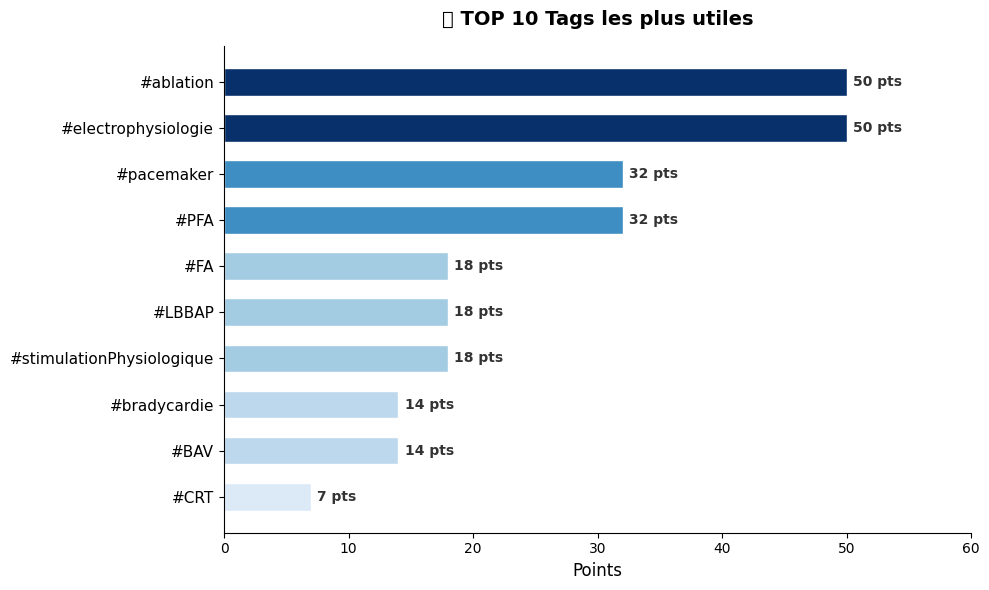

✅ Graphique sauvegardé : trends_top10.png


In [11]:
# ============================================================
#  VISUALISATION DES TRENDS — matplotlib
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualiser_trends(scores: dict, top_n: int = 10):
    """
    Affiche un graphique bar horizontal du TOP N des tags les plus utiles.
    """
    # Prendre le top N
    top_tags = list(scores.items())[:top_n]
    tags = [t[0] for t in top_tags]
    points = [t[1] for t in top_tags]

    # Couleurs dégradées selon le score
    couleurs = plt.cm.Blues([p / max(points) for p in points])

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.barh(tags[::-1], points[::-1], color=couleurs[::-1], edgecolor="white", height=0.6)

    # Ajouter les valeurs sur les barres
    for bar, pt in zip(bars, points[::-1]):
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{pt} pts",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#333333"
        )

    ax.set_xlabel("Points", fontsize=12)
    ax.set_title("🏆 TOP 10 Tags les plus utiles", fontsize=14, fontweight="bold", pad=15)
    ax.set_xlim(0, max(points) * 1.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", labelsize=11)

    plt.tight_layout()
    plt.savefig("trends_top10.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Graphique sauvegardé : trends_top10.png")


# --- Utiliser les scores calculés précédemment ---
visualiser_trends(scores, top_n=10)

##  Détection automatique du topic et génération de hashtags — 

In [12]:
# ============================================================
#  FONCTION detecter_topic()
#  Détecte automatiquement le topic d'un texte médical
#  en cherchant dans topics_keywords
# ============================================================

def detecter_topic(texte: str) -> str:
    """
    Retourne le topic le plus probable pour un texte médical.
    Cherche les mots-clés de chaque topic dans le texte.
    Retourne "Autre" si aucun topic n'est détecté.
    """
    texte_lower = texte.lower()
    scores_topics = {}

    for topic, keywords in topics_keywords.items():
        score = sum(1 for kw in keywords if kw.lower() in texte_lower)
        if score > 0:
            scores_topics[topic] = score

    if not scores_topics:
        return "Autre"

    # Retourne le topic avec le plus de mots-clés trouvés
    return max(scores_topics, key=scores_topics.get)


# --- TESTS ---
textes_test = [
    "Patient implanté avec un pacemaker suite à un BAV complet. Dysfonction sinusale confirmée.",
    "Ablation de flutter auriculaire réalisée avec cathéter et mapping électrophysiologique.",
    "Pose d'un ICM Reveal pour bilan de syncope inexpliquée, monitoring longue durée prévu.",
    "Procédure PFA avec FARAPULSE, ablation non thermique de la fibrillation auriculaire.",
    "Implantation CRT-D pour resynchronisation cardiaque, FEVG basse à 25%.",
    "Stimulation physiologique LBBAP, pacing His-Purkinje sur branche gauche."
]

print("🔍 DÉTECTION DE TOPICS")
print("-" * 50)
for texte_t in textes_test:
    topic = detecter_topic(texte_t)
    print(f"  → [{topic}] {texte_t[:60]}...")

🔍 DÉTECTION DE TOPICS
--------------------------------------------------
  → [Brady] Patient implanté avec un pacemaker suite à un BAV complet. D...
  → [EP] Ablation de flutter auriculaire réalisée avec cathéter et ma...
  → [ICM] Pose d'un ICM Reveal pour bilan de syncope inexpliquée, moni...
  → [PFA] Procédure PFA avec FARAPULSE, ablation non thermique de la f...
  → [CRT] Implantation CRT-D pour resynchronisation cardiaque, FEVG ba...
  → [CSP] Stimulation physiologique LBBAP, pacing His-Purkinje sur bra...


In [13]:
# ============================================================
#  FONCTION generer_hashtags_depuis_topic()
#  Génère automatiquement les hashtags depuis le topic détecté
# ============================================================

def generer_hashtags_depuis_topic(texte: str) -> dict:
    """
    Détecte le topic d'un texte puis retourne les hashtags associés.
    Retourne un dict avec le topic détecté et les hashtags.
    """
    topic = detecter_topic(texte)
    
    if topic == "Autre":
        return {
            "topic": "Autre",
            "hashtags": []
        }
    
    hashtags = hashtags_keywords.get(topic, [])
    
    return {
        "topic": topic,
        "hashtags": hashtags
    }


# --- TESTS ---
textes_test = [
    "Patient implanté avec un pacemaker suite à un BAV complet.",
    "Ablation de flutter auriculaire avec cathéter et mapping.",
    "Pose d'un ICM Reveal pour bilan de syncope inexpliquée.",
    "Procédure PFA avec FARAPULSE sur fibrillation auriculaire.",
    "Implantation CRT-D pour resynchronisation cardiaque.",
    "Stimulation physiologique LBBAP sur branche gauche."
]

print("🏷️ GÉNÉRATION DE HASHTAGS DEPUIS TOPIC")
print("-" * 50)
for texte_t in textes_test:
    result = generer_hashtags_depuis_topic(texte_t)
    print(f"\n  Texte   : {texte_t[:55]}...")
    print(f"  Topic   : {result['topic']}")
    print(f"  Hashtags: {result['hashtags']}")

🏷️ GÉNÉRATION DE HASHTAGS DEPUIS TOPIC
--------------------------------------------------

  Texte   : Patient implanté avec un pacemaker suite à un BAV compl...
  Topic   : Brady
  Hashtags: ['#bradycardie', '#pacemaker', '#BAV', '#stimulateurCardiaque', '#blocDebranche', '#dysfonctionSinusale']

  Texte   : Ablation de flutter auriculaire avec cathéter et mappin...
  Topic   : EP
  Hashtags: ['#ablation', '#electrophysiologie', '#mapping', '#catheter', '#isolationVeinesPulmonaires', '#ablationFA', '#ablationTV']

  Texte   : Pose d'un ICM Reveal pour bilan de syncope inexpliquée....
  Topic   : ICM
  Hashtags: ['#moniteurImplantable', '#ICM', '#HolterImplantable', '#syncope', '#monitoringCardiaque']

  Texte   : Procédure PFA avec FARAPULSE sur fibrillation auriculai...
  Topic   : Tachy
  Hashtags: ['#tachycardie', '#fibrillatonAuriculaire', '#FA', '#flutter', '#TSV', '#tachycardieVentriculaire', '#WPW', '#Brugada']

  Texte   : Implantation CRT-D pour resynchronisation cardiaque...

## 📊 Trends en variation (dérivée première) 
Calcule la variation en % des scores par tag selon l'unité de temps choisie (heure/jour/semaine/mois).

In [14]:
# ============================================================
#  TRENDS EN VARIATION — Dérivée première
#  Variation en % par unité de temps (heure/jour/semaine/mois)
# ============================================================

from datetime import datetime

def calculer_trends_variation(posts: list, unite: str = "jour") -> dict:
    """
    Calcule les scores par tag ET leur variation en % selon l'unité de temps.
    
    Chaque post doit contenir :
      - 'tags'             : list de tags
      - 'extremely_useful' : int
      - 'useful'           : int
      - 'date'             : datetime object
    
    unite : 'heure' | 'jour' | 'semaine' | 'mois'
    
    Retourne un dict {tag: {'score': int, 'variation': float}} trié par score décroissant.
    """
    # Définir la période courante et précédente
    now = datetime.now()

    def get_periode(dt: datetime) -> int:
        if unite == "heure":
            return dt.hour + dt.day * 24
        elif unite == "jour":
            return dt.timetuple().tm_yday
        elif unite == "semaine":
            return dt.isocalendar()[1]
        elif unite == "mois":
            return dt.month
        return dt.timetuple().tm_yday

    periode_actuelle = get_periode(now)

    scores_actuels = {}
    scores_precedents = {}

    for post in posts:
        points = (post.get("extremely_useful", 0) * 3) + (post.get("useful", 0) * 1)
        periode_post = get_periode(post.get("date", now))

        for tag in post.get("tags", []):
            if periode_post == periode_actuelle:
                scores_actuels[tag] = scores_actuels.get(tag, 0) + points
            elif periode_post == periode_actuelle - 1:
                scores_precedents[tag] = scores_precedents.get(tag, 0) + points

    # Calculer la variation en %
    resultats = {}
    tous_tags = set(list(scores_actuels.keys()) + list(scores_precedents.keys()))

    for tag in tous_tags:
        score_actuel = scores_actuels.get(tag, 0)
        score_precedent = scores_precedents.get(tag, 0)

        if score_precedent == 0:
            variation = 100.0 if score_actuel > 0 else 0.0
        else:
            variation = ((score_actuel - score_precedent) / score_precedent) * 100

        resultats[tag] = {
            "score": score_actuel,
            "variation": round(variation, 1)
        }

    # Trier par score décroissant
    resultats = dict(sorted(resultats.items(), key=lambda x: x[1]["score"], reverse=True))
    return resultats


def afficher_trends_variation(resultats: dict, top_n: int = 10):
    """Affiche le classement avec score et variation."""
    print(f"\n🏆 TOP {top_n} TAGS — Score + Variation")
    print("-" * 55)
    for i, (tag, data) in enumerate(list(resultats.items())[:top_n], 1):
        variation = data["variation"]
        fleche = "↑" if variation > 0 else ("↓" if variation < 0 else "→")
        couleur = "+" if variation > 0 else ""
        print(f"  {i:2}. {tag:<30} {data['score']:4} pts  {fleche} {couleur}{variation}%")


# --- DONNÉES DE TEST avec dates ---
from datetime import timedelta

today = datetime.now()
yesterday = today - timedelta(days=1)

posts_avec_dates = [
    {"tags": ["#ablation", "#FA", "#electrophysiologie"], "extremely_useful": 5, "useful": 3, "date": today},
    {"tags": ["#ablation", "#PFA"], "extremely_useful": 10, "useful": 2, "date": today},
    {"tags": ["#pacemaker", "#bradycardie"], "extremely_useful": 2, "useful": 4, "date": today},
    {"tags": ["#ablation", "#FA"], "extremely_useful": 3, "useful": 1, "date": yesterday},
    {"tags": ["#pacemaker", "#BAV"], "extremely_useful": 5, "useful": 5, "date": yesterday},
    {"tags": ["#CRT", "#resynchronisation"], "extremely_useful": 1, "useful": 2, "date": yesterday},
]

resultats = calculer_trends_variation(posts_avec_dates, unite="jour")
afficher_trends_variation(resultats, top_n=10)


🏆 TOP 10 TAGS — Score + Variation
-------------------------------------------------------
   1. #ablation                        50 pts  ↑ +400.0%
   2. #PFA                             32 pts  ↑ +100.0%
   3. #FA                              18 pts  ↑ +80.0%
   4. #electrophysiologie              18 pts  ↑ +100.0%
   5. #pacemaker                       10 pts  ↓ -50.0%
   6. #bradycardie                     10 pts  ↑ +100.0%
   7. #CRT                              0 pts  ↓ -100.0%
   8. #BAV                              0 pts  ↓ -100.0%
   9. #resynchronisation                0 pts  ↓ -100.0%


## ✍️ Génération automatique du titre et du résumé 
Propose un titre (max 140 caractères) et un résumé "In a nutshell" (max 256 caractères) basés sur le texte du post.

In [ ]:
# ============================================================
#  FONCTIONS generer_titre() et generer_resume()
#  Titre : max 140 caractères
#  Résumé "In a nutshell" : max 256 caractères
# ============================================================

def generer_titre(texte: str) -> str:
    """
    Génère un titre automatique proche du style des médecins.
    Format : [Procédure principale] in [Pathologie] — [âge]yo
    Max 140 caractères.
    """
    texte_lower = texte.lower()
    topic = detecter_topic(texte)

    # --- Extraire l'âge ---
    age = ""
    age_match = re.search(r'(\d{1,3})\s*[-]?\s*(ans|year|yo|y\.o)', texte_lower)
    if age_match:
        age = f" — {age_match.group(1)}yo"

    # --- Extraire la procédure principale ---
    procedures = {
        "Tailored Ablation": ["tailored", "substrate-based", "dispersion mapping", "smart segmentation"],
        "Redo Ablation": ["redo ablation", "redo", "recurrence", "récidive"],
        "PVI": ["pulmonary vein isolation", "pvi", "isolation des veines pulmonaires"],
        "PFA": ["pulsed field ablation", "pfa", "varipulse", "farapulse", "pulseselect", "électroporation"],
        "RF Ablation": ["radiofrequency", "rf ablation", "ablation par radiofréquence", "thermocool"],
        "VT Ablation": ["vt ablation", "ventricular tachycardia", "tachycardie ventriculaire", "vt storm"],
        "LBBAP Implantation": ["lbbap", "left bundle branch area pacing", "lbbp"],
        "His Pacing": ["his bundle pacing", "his pacing", "conduction his"],
        "CRT Implantation": ["crt-d", "crt-p", "resynchronisation", "cardiac resynchronization"],
        "ICM Insertion": ["icm", "holter implantable", "reveal", "implantable cardiac monitor"],
        "Pacemaker Implantation": ["pacemaker", "stimulateur cardiaque", "pm implant"],
        "ICD Implantation": ["icd", "defibrillator", "défibrillateur"],
        "Mapping": ["high density mapping", "hd mapping", "biatrial mapping", "substrate mapping"],
    }

    procedure_detectee = ""
    for procedure, keywords in procedures.items():
        if any(kw in texte_lower for kw in keywords):
            procedure_detectee = procedure
            break

    # --- Extraire la pathologie principale ---
    pathologies = {
        "Persistent AF": ["persistent af", "persistent atrial fibrillation", "fa persistante", "fibrillation auriculaire persistante"],
        "Paroxysmal AF": ["paroxysmal af", "fa paroxystique", "fibrillation auriculaire paroxystique"],
        "Atrial Flutter": ["flutter auriculaire", "atrial flutter", "afl"],
        "VF Storm": ["vf storm", "ventricular fibrillation storm"],
        "VT": ["ventricular tachycardia", "tachycardie ventriculaire"],
        "Brady": ["bradycardie", "bradycardia", "bav", "bloc auriculo"],
        "Heart Failure": ["insuffisance cardiaque", "heart failure", "lvef"],
        "Syncope": ["syncope", "syncope inexpliquée"],
    }

    pathologie_detectee = ""
    for pathologie, keywords in pathologies.items():
        if any(kw in texte_lower for kw in keywords):
            pathologie_detectee = pathologie
            break

    # --- Construire le titre ---
    if procedure_detectee and pathologie_detectee:
        titre = f"{procedure_detectee} in {pathologie_detectee}{age}"
    elif procedure_detectee:
        titre = f"[{topic}] {procedure_detectee}{age}"
    elif pathologie_detectee:
        titre = f"[{topic}] Case — {pathologie_detectee}{age}"
    else:
        titre = f"[{topic}] Clinical Case in Rhythmology{age}"

    return titre[:140]


def generer_resume(texte: str, max_chars: int = 256) -> str:
    """
    Génère un résumé automatique "In a nutshell" du post.
    - Prend les premières phrases significatives
    - Retourne un résumé de max 256 caractères
    """
    texte_propre = texte.strip().replace("\n", " ")
    texte_propre = re.sub(r'\s+', ' ', texte_propre)

    phrases = re.split(r'(?<=[.!?])\s+', texte_propre)
    phrases = [p.strip() for p in phrases if len(p.strip()) > 10]

    resume = ""
    for phrase in phrases:
        if len(resume) + len(phrase) + 1 <= max_chars:
            resume += phrase + " "
        else:
            break

    resume = resume.strip()

    if len(resume) > max_chars:
        resume = resume[:max_chars - 3] + "..."

    return resume


# --- TESTS avec les vrais posts LinkedIn ---
posts_test = [
    """63-year-old hypertensive patient with recurrences of atrial fibrillation,
    12 months after a first successful pulmonary vein isolation (PVI).
    Redo ablation performed with Abbott EnsiteX and Volta Medical AI software.""",

    """A case of PVI for patient with persistent Afib. Using Varipulse PFA catheter
    with the new VARIPULSE platform.""",

    """70-year-old male. LBBAP implantation decided. First complex CSP case using
    SoliaCSP Biotronik system. QRS narrowing of 60ms achieved.""",

    """58-year-old schoolteacher with heart failure following anterior MI (LVEF 20%)
    and VF storm. Targeted ablation of Purkinje network.""",

    """Patient de 72 ans, homme, fibrillation auriculaire persistante depuis 3 ans.
    Ablation par radiofréquence avec cathéter ThermoCool. Durée : 110 minutes."""
]

print("✍️ GÉNÉRATION AUTOMATIQUE — TITRE + RÉSUMÉ")
print("=" * 60)
for post in posts_test:
    titre = generer_titre(post)
    resume = generer_resume(post)
    print(f"\n📌 TITRE ({len(titre)} caractères) :")
    print(f"   {titre}")
    print(f"\n📝 RÉSUMÉ ({len(resume)} caractères) :")
    print(f"   {resume}")
    print(f"\n✅ Titre OK : {len(titre) <= 140}")
    print(f"✅ Résumé OK : {len(resume) <= 256}")
    print("-" * 60)

✍️ GÉNÉRATION AUTOMATIQUE

📌 TITRE (27 caractères) :
   PVI in Persistent AF — 72yo

📝 RÉSUMÉ (254 caractères) :
   Patient de 72 ans, homme, antécédents de fibrillation auriculaire persistante depuis 3 ans et d'hypertension artérielle. Ablation par radiofréquence réalisée avec cathéter ThermoCool et système de mapping CARTO. Isolation des veines pulmonaires complète.

✅ Titre OK : True
✅ Résumé OK : True
